This sources adapted from myoconverter to manually check the optimization result

# References

https://github.com/MyoHub/myoconverter/blob/main/myoconverter/conversion_steps/O2MStep2.py

# Common Libraries

In [1]:
import os, sys, pickle, itertools
import numpy as np
import matplotlib.pylab as plt

if "CONDA_PREFIX" not in os.environ:
    os.environ["CONDA_PREFIX"] = sys.prefix
import mujoco
from mujoco import MjModel, mjtObj

# Custom Libraries

In [2]:
myoconverter_path = "/home/seojin/biomechanics_tools/myoconverter"
sys.path.append(myoconverter_path)

sys.path.append("/home/seojin/Seojin_commonTool/Module")
from opensim_util import extract_muscle_names

from validation_util import plot_moment_arm

# Functions

In [3]:
def maVectorSort(ma_vec, nJnt, nEval):
    """
    This function sort the moment arm vector that generated by optimization procedures.
    Results of this sort function are joint specific lists that contains the moment arms
    of it. The number of list depends on the mesh points of the other coupled joints. The
    length of each list represent the checking points of this joint angle.

    In the optimization, itertools.product will generate the angle mesh list in this structure:
      [Ang11, Ang21, Ang31], [Ang11, Ang21, Ang32], ...
      [Ang11, Ang22, Ang31], [Ang11, Ang22, Ang32], ...
      ...
      [Ang12, Ang21, Ang31], [Ang12, Ang21, Ang32], ...
      ...
      ...
    """

    """
    
    return: np.array(shape: #joint, #joint_angle, #joint_angle_configuration)
        - #joint: the number of target joints related to a muscle
        - #joint_angle: the number of joint angles of target joint
        - #joint_angle_configuration: all possible joint angle combinations of the other coupled joints
    """
    # run through each joint
    ma_mat = np.zeros((nJnt, nEval, nEval**(nJnt-1)))

    for nj in range(nJnt):  # run through joints
        njVec = ma_vec[nj]

        for ne in range(nEval):  # run through evaulation joints
            for ne2 in range(nEval**(nJnt-1)):
                ma_mat[nj, ne, ne2] = ma_vec[ne*nEval**(nJnt-1) + ne2][nj]

    return ma_mat

In [4]:
def computeMomentArmMuscleJoints(mj_model, muscle, joints, ang_ranges, evalN):
    """
    Calculate moment arm matries from given muscles and joints
    """
    mj_data = mujoco.MjData(mjc_model)
    mj_model.opt.timestep = 0.001 ## same time step as opensim
    
    muscle_id = mujoco.mj_name2id(mjc_model, mujoco.mjtObj.mjOBJ_ACTUATOR, muscle)
    joint_ids = [mujoco.mj_name2id(mjc_model, mujoco.mjtObj.mjOBJ_JOINT, joint) for joint in joints]
    angle_grids = [np.linspace(angle_range[0], angle_range[1], evalN) for angle_range in ang_ranges]

    moment_arms = []
    for angles in itertools.product(*angle_grids):
        # Set joint configuration
        mj_data.qpos[:] = 0
        mj_data.qvel[:] = 0
        mj_data.qpos[joint_ids] = angles

        # assign the value of dependency joints
        dependencyJnts, dependencyJntAngs, freeJnts = dependencyJointAng(mjc_model, joint_ids, angles)
        mj_data.qpos[dependencyJnts] = dependencyJntAngs

        # assign the value of locked joints
        lockedJnts, lockedJointAngs = lockedJointAng(mjc_model)
        mj_data.qpos[lockedJnts] = lockedJointAngs

        # Forward dynamics
        mujoco.mj_step(mjc_model, mj_data)

        # Stack data
        moment_arms.append(mj_data.actuator_moment[muscle_id, joint_ids].copy())

    result = np.array(moment_arms)
    return result

In [5]:
def dependencyJointAng(mj_model, free_jnt_ids, jnt_angles):
    free_jnt_ids = np.asarray(free_jnt_ids)
    jnt_angles = np.asarray(jnt_angles)

    dep_jnts, dep_angles, free_jnts = [], [], []

    eq_ids = np.where(
        (mj_model.eq_type == mujoco.mjtEq.mjEQ_JOINT) &
        (mj_model.eq_active == 1)
    )[0]

    for eq_id in eq_ids:
        dep_jnt = mj_model.eq_obj1id[eq_id]
        free_jnt = mj_model.eq_obj2id[eq_id]

        if free_jnt not in free_jnt_ids:
            continue

        if dep_jnt in dep_jnts:
            raise RuntimeError("Multiple equality constraints for one dependent joint.")

        free_angle = jnt_angles[np.where(free_jnt_ids == free_jnt)[0][0]]
        coefs = mj_model.eq_data[eq_id][:5]

        dep_angle = np.polyval(coefs[::-1], free_angle)

        dep_jnts.append(dep_jnt)
        dep_angles.append(dep_angle)
        free_jnts.append(free_jnt)

    return dep_jnts, dep_angles, free_jnts

In [6]:
def lockedJointAng(mjc_model):
    """
    Find locked joints and their fixed angles.
    """

    locked_eq_ids = np.where(
        (mjc_model.eq_type == mujoco.mjtEq.mjEQ_JOINT) &
        (mjc_model.eq_active == 1) &
        (mjc_model.eq_obj2id == -1)
    )[0]

    locked_jnts = mjc_model.eq_obj1id[locked_eq_ids].tolist()
    locked_angles = mjc_model.eq_data[locked_eq_ids, 0].tolist()

    return locked_jnts, locked_angles

# Params

In [7]:
experiment_type = "real"
subj_number = "1"
measurement_type = "mri"

muscle = "TMIN"
is_save_img = False

# Constants

In [8]:
# Opensim
osim_model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_emg/Opensim/Model/scaled_model.osim"

# Myosuite
myosuite_dir_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_emg/Myosuite/scaled_model"
cvt2_model_path = os.path.join(myosuite_dir_path, "scaled_model_cvt2.xml")
optimization_dir_path = os.path.join(myosuite_dir_path, "Step2_muscleKinematics")
output_dir_path = "/mnt/ext1/seojin/temp/validation"
os.makedirs(output_dir_path, exist_ok = True)

# Model

In [9]:
muscle_list = extract_muscle_names(osim_model_path)
mjc_model = MjModel.from_xml_path(cvt2_model_path)

# Load muscle optimization result

In [10]:
path = os.path.join(optimization_dir_path, f"{muscle}.pkl")
with open(path, "rb") as muscle_file:
    muscle_para_opt = pickle.load(muscle_file)

# Generate the moment arm curves for comparison plots. 

- Moment arm of Osim model will just use the reference data that pre-generated for optimization.
- Moment arm of Mjc model will be regenerated to increase the mesh density.

This is to check if there are any random jumpping paths (that were not covered by the optimization)

**wrapping_coordinates**: the names of joint angle which muscle affects and pass through  
**moment arm matrix**: It represents the moment arm, which defines the mechanical relationship between a muscle and a joint, across various body configurations

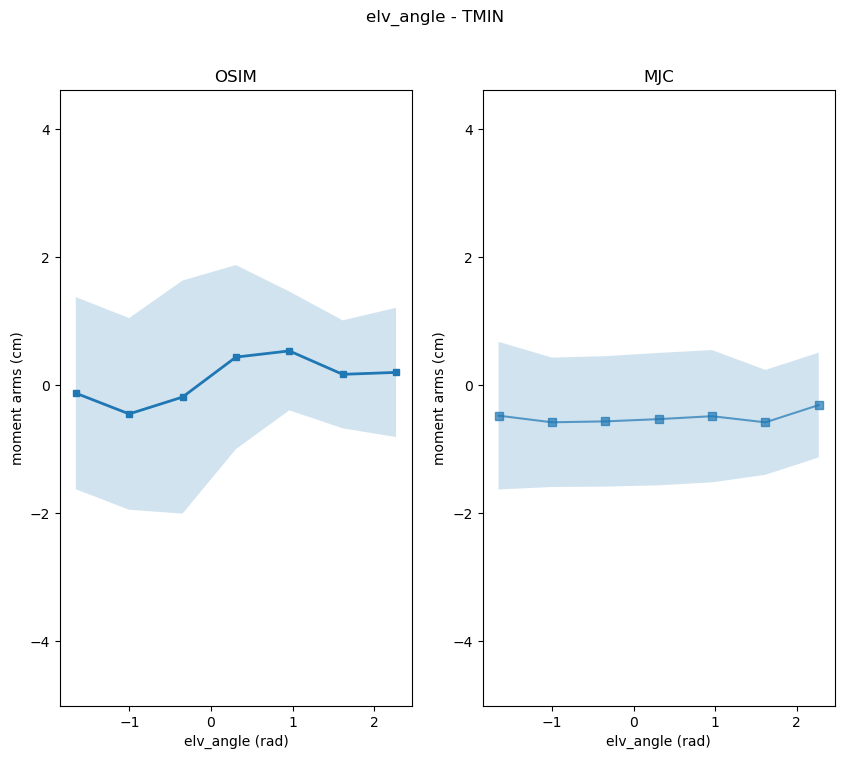

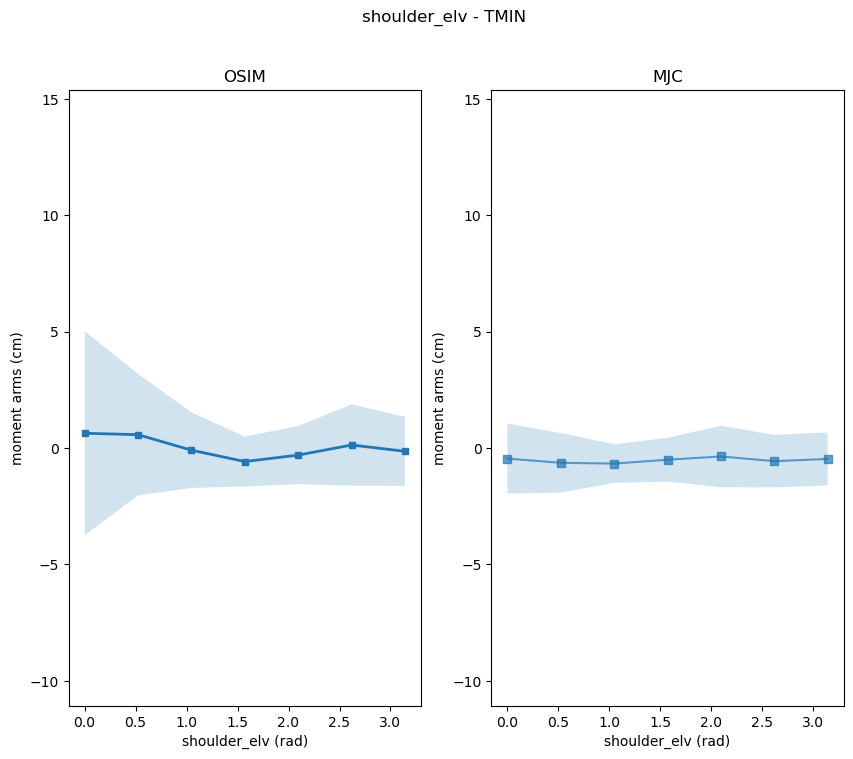

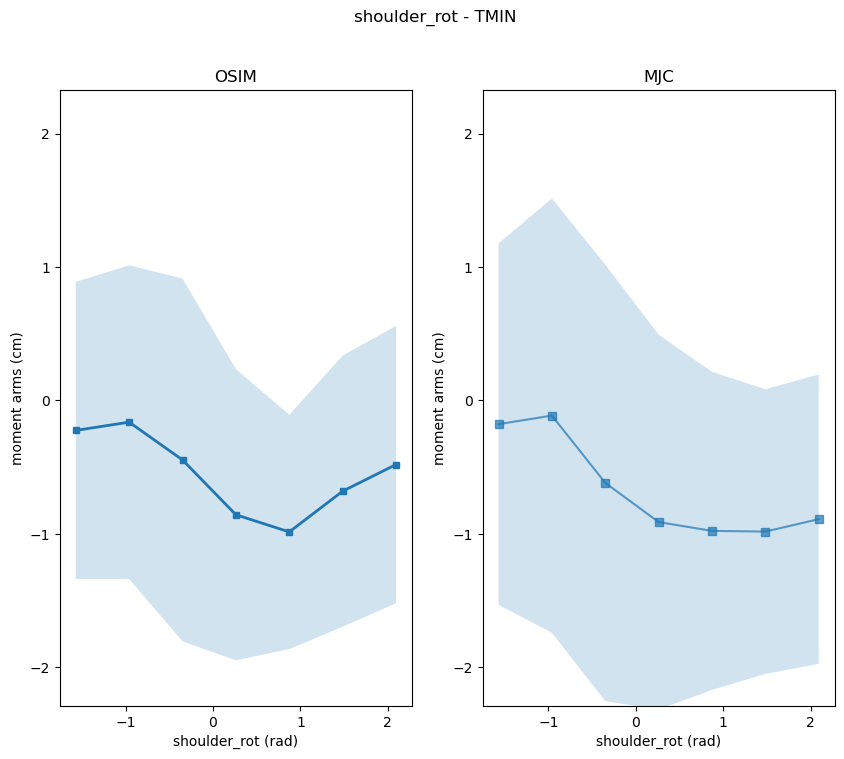

In [11]:
for i, related_joints in enumerate(muscle_para_opt["wrapping_coordinates"]):
    # The number of sample points across the joint's Range of Motion
    n_evals = muscle_para_opt["evalN"][i]
    n_related_joints = len(related_joints)

    # Mujoco moment arm matrix
    mjc_joint_ranges = muscle_para_opt['mjc_coordinate_ranges'][i]
    mjc_momentArm_vector = computeMomentArmMuscleJoints(mjc_model, muscle, related_joints, mjc_joint_ranges, n_evals)
    mjc_momentArm_matrix = maVectorSort(mjc_momentArm_vector, n_related_joints, n_evals)

    # Opensim moment arm matrix
    osim_joint_ranges = muscle_para_opt['osim_coordinate_ranges'][i]
    osim_momentArm_matrix = maVectorSort(muscle_para_opt['osim_ma_data'][i], n_related_joints, n_evals)
        
    # Plot
    for j, joint in enumerate(related_joints):
        if is_save_img:
            moment_arm_plot_path = os.path.join(output_dir_path, f"{joint}_and_{muscle}.png")
        else:
            moment_arm_plot_path = None
        plot_moment_arm(muscle_name = muscle, 
                        joint_name = joint,
                        joint_range_osim = osim_joint_ranges[j], 
                        joint_range_mjc = mjc_joint_ranges[j], 
                        ma_mat_osim = osim_momentArm_matrix[j], 
                        ma_mat_mjc = mjc_momentArm_matrix[j],
                        n_evals = n_evals,
                        n_joint = n_related_joints,
                        save_img_path = moment_arm_plot_path,
                        is_aggregation = True)